# 1.10 Execution Repricing Calibration: EIP-8038, EIP-2780, and EIP-7904

This notebook estimates the execution metering multiplier needed by the Glamsterdam and EIP-7999 equilibrium notebooks. It re-prices the February–May 2026 historical transaction path under two requested cases:

1. **EIP-8038 + EIP-2780**
2. **EIP-8038 + EIP-2780 + EIP-7904**

The current EIP-7904 is an informational compute-cost analysis that specifies **no gas-schedule changes**. The two cases are therefore numerically identical under the current EIP text. The notebook keeps both labels so that this conclusion is visible and so a future consensus 7904 schedule cannot be introduced silently.

EIP-2780 also does not replace every 21,000 intrinsic charge with 12,000. The 12,000 value is the sender component. Recipient access, value transfer, transfer-log, delegation, and contract-creation components are added according to the transaction path.

The headline result also rebuilds EIP-8038's transaction refund counter over the **complete 120-day Xatu range** and reapplies the 20% cap. The refund reconstruction itself is Xatu-only; the small access-list and authorization-write terms retain the pre-existing RPC calibration because Xatu does not expose their complete transaction contents.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})
import numpy as np
import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from sim.xatu_refunds import query_xatu_refund_daily_full

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

NETWORK = "mainnet"
START_DATE = "2026-02-01"
END_DATE = "2026-06-01"  # exclusive
TAG = f"{START_DATE}_{END_DATE}"
REFRESH_XATU = False
REFRESH_REFUNDS = False
WRITE_CSV = True

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

ACCOUNTING_CSV = DATA_DIR / f"daily_accounting_panel_calibrated_with_bal_{TAG}.csv"
CURRENT_DATA_CSV = DATA_DIR / f"daily_current_data_gas_xatu_{TAG}.csv"
RPC_SAMPLE_CSV = DATA_DIR / f"calibration_rpc_state_access_auth_blocks_{TAG}.csv"
OPS_CACHE_CSV = DATA_DIR / f"xatu_daily_execution_repricing_ops_{TAG}.csv"
CALLS_CACHE_CSV = DATA_DIR / f"xatu_daily_execution_repricing_calls_{TAG}.csv"
TX_CACHE_CSV = DATA_DIR / f"xatu_daily_eip2780_transaction_types_{TAG}.csv"
REFUND_CACHE_CSV = DATA_DIR / f"xatu_full_refund_daily_{TAG}.csv"

OUT_DAILY_CSV = DATA_DIR / f"execution_repricing_daily_{TAG}.csv"
OUT_SCENARIOS_CSV = DATA_DIR / f"execution_repricing_scenarios_{TAG}.csv"
OUT_SPEC_CSV = DATA_DIR / f"execution_repricing_spec_card_{TAG}.csv"
OUT_PLOT = PLOTS_DIR / f"execution_repricing_8038_2780_{TAG}.png"

## Protocol parameter card

The parameter card records the values used in the calculation. EIP-2780's 12,000 sender charge is combined with the relevant recipient and value-transfer charges; it is never applied as a blanket transaction cost.


In [2]:
WARM_ACCESS_CURRENT = 100
COLD_STORAGE_CURRENT_SURCHARGE = 2_100
SSTORE_FIRST_CHANGE_CURRENT = 2_800
SSTORE_NEW_SLOT_EXTRA_CURRENT = 17_100
CURRENT_STORAGE_CREATION_GAS = 20_000
CURRENT_NEW_ACCOUNT_GAS = 25_000
CURRENT_CREATE_GAS = 32_000

COLD_ACCOUNT_8038 = 3_000
COLD_STORAGE_8038 = 3_000
STORAGE_WRITE_8038 = 10_000
CREATE_ACCESS_8038 = 11_000
DELTA_COLD_ACCOUNT_8038 = 400
DELTA_COLD_STORAGE_8038 = 900
DELTA_ACCOUNT_WRITE_8038 = 1_300
DELTA_ACCESS_LIST_ADDRESS_8038 = 600
DELTA_ACCESS_LIST_KEY_8038 = 1_100
EXT_SECOND_READ_8038 = 100

TX_BASE_2780 = 12_000
TX_VALUE_2780 = 4_244
TRANSFER_LOG_2780 = 1_756
CURRENT_EIP7904_COMPUTE_DELTA = 0

spec_card = pd.DataFrame([
    ("EIP-8038", "cold account access", 2_600, COLD_ACCOUNT_8038, "regular gas"),
    ("EIP-8038", "cold storage access", 2_100, COLD_STORAGE_8038, "regular gas"),
    ("EIP-8038", "storage first-change write", 2_800, STORAGE_WRITE_8038, "regular gas"),
    ("EIP-8038", "account write", 6_700, 8_000, "regular gas"),
    ("EIP-8038", "CREATE access", 7_000, CREATE_ACCESS_8038, "regular gas after EIP-8037 split"),
    ("EIP-8038", "access-list address", 2_400, 3_000, "regular intrinsic gas"),
    ("EIP-8038", "access-list storage key", 1_900, 3_000, "regular intrinsic gas"),
    ("EIP-2780", "sender component", 21_000, TX_BASE_2780, "not a standalone transaction total"),
    ("EIP-2780", "recipient value-write component", 0, TX_VALUE_2780, "regular gas when value moves"),
    ("EIP-2780", "ETH transfer log", 0, TRANSFER_LOG_2780, "regular gas when value moves"),
    ("EIP-7904", "compute schedule", 0, CURRENT_EIP7904_COMPUTE_DELTA, "current EIP specifies no changes"),
], columns=["eip", "parameter", "current_value", "counterfactual_value", "accounting"])
spec_card.to_csv(OUT_SPEC_CSV, index=False)
spec_card


,eip,parameter,current_value,counterfactual_value,accounting
0,EIP-8038,cold account access,2600,3000,regular gas
1,EIP-8038,cold storage access,2100,3000,regular gas
2,EIP-8038,storage first-change write,2800,10000,regular gas
3,EIP-8038,account write,6700,8000,regular gas
4,EIP-8038,CREATE access,7000,11000,regular gas after EIP-8037 split
5,EIP-8038,access-list address,2400,3000,regular intrinsic gas
6,EIP-8038,access-list storage key,1900,3000,regular intrinsic gas
7,EIP-2780,sender component,21000,12000,not a standalone transaction total
8,EIP-2780,recipient value-write component,0,4244,regular gas when value moves
9,EIP-2780,ETH transfer log,0,1756,regular gas when value moves


## Historical anchors and sampled intrinsic fields

The denominator matches notebooks 1.9 and 2.0: receipt gas minus current-rule data gas and minus the calibrated historical state-creation proxy. This is the current regular-execution quantity to which the execution multiplier will be applied.

Xatu does not expose transaction access-list contents in the raw transaction table. Address, storage-key, and successful authorization-write rates therefore come from the existing RPC sample, mapped to each sample block's date. These are small calibrated components; the opcode and transaction-path components use the complete 120-day Xatu panel.


In [3]:
accounting = pd.read_csv(ACCOUNTING_CSV)
current_data = pd.read_csv(CURRENT_DATA_CSV)[["date", "data_gas_current"]]
accounting = accounting.merge(current_data, on="date", how="left", validate="one_to_one")
accounting["date"] = pd.to_datetime(accounting["date"])
if accounting["data_gas_current"].isna().any():
    raise ValueError("Current-rule data gas is missing for one or more accounting days")
if len(accounting) != 120:
    raise ValueError(f"Expected 120 accounting days, found {len(accounting)}")

accounting["execution_current"] = (
    accounting["current_gas_used"]
    - accounting["data_gas_current"]
    - accounting["current_state_creation_gas_calibrated"]
)
if accounting["execution_current"].le(0).any():
    raise ValueError("Current regular execution gas must be positive on every day")

rpc = pd.read_csv(RPC_SAMPLE_CSV).sort_values("block_number")
day_bounds = accounting[["date", "min_block", "max_block"]].sort_values("min_block")
rpc = pd.merge_asof(
    rpc, day_bounds, left_on="block_number", right_on="min_block", direction="backward"
)
if rpc["date"].isna().any() or (rpc["block_number"] > rpc["max_block"]).any():
    raise ValueError("One or more RPC sample blocks could not be mapped to an accounting date")
rpc["eoa_account_write_count"] = (
    rpc["authorization_set_tuple_count"] + rpc["authorization_clear_tuple_count"]
)
sample_daily = rpc.groupby("date", as_index=False).agg(
    rpc_sampled_blocks=("block_number", "nunique"),
    access_list_address_count_sample=("tx_access_list_address_count", "sum"),
    access_list_key_count_sample=("tx_access_list_storage_key_count", "sum"),
    eoa_account_write_count_sample=("eoa_account_write_count", "sum"),
)
for col in ["access_list_address_count", "access_list_key_count", "eoa_account_write_count"]:
    sample_daily[f"{col}_per_block"] = sample_daily[f"{col}_sample"] / sample_daily["rpc_sampled_blocks"]

accounting = accounting.merge(
    sample_daily[["date", "rpc_sampled_blocks", "access_list_address_count_per_block",
                  "access_list_key_count_per_block", "eoa_account_write_count_per_block"]],
    on="date", how="left", validate="one_to_one"
)
rpc_rate_columns = {
    "access_list_address_count": "tx_access_list_address_count",
    "access_list_key_count": "tx_access_list_storage_key_count",
    "eoa_account_write_count": "eoa_account_write_count",
}
for col, rpc_col in rpc_rate_columns.items():
    pooled_rate = rpc[rpc_col].sum() / rpc["block_number"].nunique()
    accounting[f"{col}_per_block"] = accounting[f"{col}_per_block"].fillna(pooled_rate)
    accounting[col] = accounting[f"{col}_per_block"] * accounting["block_count"]

display(accounting[["date", "block_count", "execution_current", "rpc_sampled_blocks"]].head())
print(f"accounting blocks: {accounting['block_count'].sum():,.0f}; RPC sample blocks: {rpc['block_number'].nunique():,}")


,date,block_count,execution_current,rpc_sampled_blocks
0,2026-02-01,7161,"177,000,220,482.000000",50
1,2026-02-02,7160,"178,241,299,414.000000",50
2,2026-02-03,7149,"175,423,901,380.000000",50
3,2026-02-04,7152,"180,433,219,324.000000",50
4,2026-02-05,7150,"184,510,416,448.000000",50


accounting blocks: 860,505; RPC sample blocks: 5,997


## Full-panel Xatu trace extraction

Three cached daily extracts keep the notebook reproducible:

- opcode aggregates measure cold touches, SSTORE gas, CREATE attempts, EXTCODE second reads, and refund counters;
- call traces identify successful internal creates and positive-value `CALL`/`CALLCODE` operations;
- transactions identify EIP-2780 intrinsic paths.

The connection is opened only when a cache is missing or `REFRESH_XATU=True`.


In [4]:
cache_paths = [OPS_CACHE_CSV, CALLS_CACHE_CSV, TX_CACHE_CSV]
need_xatu = REFRESH_XATU or any(not path.exists() for path in cache_paths)
raw_client = None
if need_xatu:
    import clickhouse_connect
    load_dotenv(PROJECT_ROOT / ".env")
    missing = [name for name in ["CLICKHOUSE_USER", "CLICKHOUSE_PASSWORD"] if not os.environ.get(name)]
    if missing:
        raise RuntimeError("Missing .env values: " + ", ".join(missing))
    raw_client = clickhouse_connect.get_client(
        host=os.environ.get("CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io"),
        port=int(os.environ.get("CLICKHOUSE_PORT", "443")),
        secure=True,
        username=os.environ["CLICKHOUSE_USER"],
        password=os.environ["CLICKHOUSE_PASSWORD"],
    )
    print("Xatu", raw_client.query("SELECT version()").result_rows)
else:
    print("using cached Xatu extracts")

MIN_BLOCK = int(accounting["min_block"].min())
MAX_BLOCK = int(accounting["max_block"].max())
PARAMS = {"network": NETWORK, "min_block": MIN_BLOCK, "max_block": MAX_BLOCK}

def normalize_date(df):
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])
    return out

def load_or_query(path, query):
    if path.exists() and not REFRESH_XATU:
        print("loaded", path)
        return normalize_date(pd.read_csv(path))
    out = normalize_date(raw_client.query_df(query, parameters=PARAMS, settings={"max_execution_time": 900}))
    if WRITE_CSV:
        out.to_csv(path, index=False)
        print("wrote", path)
    return out


using cached Xatu extracts


In [5]:
OPS_QUERY = r"""
WITH op_by_block AS
(
    SELECT
        block_number,
        uniqExact(transaction_hash) AS traced_txs,
        sumIf(opcode_count, operation = 'SSTORE') AS sstore_count,
        sumIf(gas, operation = 'SSTORE') AS sstore_gas_current,
        sumIf(cold_access_count, operation = 'SSTORE') AS sstore_cold_count,
        sumIf(cold_access_count, operation = 'SLOAD') AS sload_cold_count,
        sumIf(cold_access_count, operation IN (
            'BALANCE', 'EXTCODEHASH', 'EXTCODESIZE', 'EXTCODECOPY',
            'CALL', 'CALLCODE', 'DELEGATECALL', 'STATICCALL', 'SELFDESTRUCT'
        )) AS account_cold_count,
        sumIf(opcode_count, operation IN ('EXTCODESIZE', 'EXTCODECOPY')) AS ext_second_read_count,
        sumIf(opcode_count, operation IN ('CREATE', 'CREATE2')) AS internal_create_opcode_count,
        sumIf(opcode_count, operation = 'SELFDESTRUCT') AS selfdestruct_count,
        sumIf(ifNull(gas_refund, 0), operation = '' AND call_frame_id = 0) AS refund_counter_current
    FROM default.canonical_execution_transaction_structlog_agg FINAL
    WHERE meta_network_name = {network:String}
      AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
    GROUP BY block_number
)
SELECT
    toDate(b.block_date_time) AS date,
    countIf(o.traced_txs > 0) AS blocks_with_traces,
    sum(ifNull(o.traced_txs, 0)) AS traced_txs,
    sum(ifNull(o.sstore_count, 0)) AS sstore_count,
    sum(ifNull(o.sstore_gas_current, 0)) AS sstore_gas_current,
    sum(ifNull(o.sstore_cold_count, 0)) AS sstore_cold_count,
    sum(ifNull(o.sload_cold_count, 0)) AS sload_cold_count,
    sum(ifNull(o.account_cold_count, 0)) AS account_cold_count,
    sum(ifNull(o.ext_second_read_count, 0)) AS ext_second_read_count,
    sum(ifNull(o.internal_create_opcode_count, 0)) AS internal_create_opcode_count,
    sum(ifNull(o.selfdestruct_count, 0)) AS selfdestruct_count,
    sum(ifNull(o.refund_counter_current, 0)) AS refund_counter_current
FROM default.canonical_execution_block AS b FINAL
GLOBAL LEFT JOIN op_by_block AS o USING block_number
WHERE b.meta_network_name = {network:String}
  AND b.block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
GROUP BY date
ORDER BY date
"""

CALLS_QUERY = r"""
WITH calls_by_block AS
(
    SELECT
        block_number,
        countIf(
            action_type = 'call' AND trace_address IS NOT NULL
            AND action_call_type IN ('call', 'call_code') AND action_value > 0
        ) AS positive_value_internal_calls,
        countIf(action_type = 'create' AND trace_address IS NOT NULL) AS internal_create_traces,
        countIf(
            action_type = 'create' AND trace_address IS NOT NULL
            AND error IS NULL AND result_address IS NOT NULL
        ) AS successful_internal_creates
    FROM default.canonical_execution_traces FINAL
    WHERE meta_network_name = {network:String}
      AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
    GROUP BY block_number
)
SELECT
    toDate(b.block_date_time) AS date,
    sum(ifNull(c.positive_value_internal_calls, 0)) AS positive_value_internal_calls,
    sum(ifNull(c.internal_create_traces, 0)) AS internal_create_traces,
    sum(ifNull(c.successful_internal_creates, 0)) AS successful_internal_creates
FROM default.canonical_execution_block AS b FINAL
GLOBAL LEFT JOIN calls_by_block AS c USING block_number
WHERE b.meta_network_name = {network:String}
  AND b.block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
GROUP BY date
ORDER BY date
"""

TX_QUERY = r"""
WITH tx_by_block AS
(
    SELECT
        block_number,
        count() AS tx_count_trace_input,
        countIf(`to` IS NOT NULL AND lower(`from`) = lower(`to`)) AS self_txs,
        countIf(`to` IS NOT NULL AND lower(`from`) != lower(`to`) AND value = 0) AS distinct_zero_value_txs,
        countIf(`to` IS NOT NULL AND lower(`from`) != lower(`to`) AND value > 0) AS distinct_value_txs,
        countIf(`to` IS NULL AND success AND value = 0) AS create_success_zero_value,
        countIf(`to` IS NULL AND success AND value > 0) AS create_success_value,
        countIf(`to` IS NULL AND NOT success AND value = 0) AS create_failed_zero_value,
        countIf(`to` IS NULL AND NOT success AND value > 0) AS create_failed_value,
        countIf(type = 4) AS type4_txs
    FROM default.execution_transaction FINAL
    WHERE meta_network_name = {network:String}
      AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
    GROUP BY block_number
)
SELECT
    toDate(b.block_date_time) AS date,
    sum(ifNull(t.tx_count_trace_input, 0)) AS tx_count_trace_input,
    sum(ifNull(t.self_txs, 0)) AS self_txs,
    sum(ifNull(t.distinct_zero_value_txs, 0)) AS distinct_zero_value_txs,
    sum(ifNull(t.distinct_value_txs, 0)) AS distinct_value_txs,
    sum(ifNull(t.create_success_zero_value, 0)) AS create_success_zero_value,
    sum(ifNull(t.create_success_value, 0)) AS create_success_value,
    sum(ifNull(t.create_failed_zero_value, 0)) AS create_failed_zero_value,
    sum(ifNull(t.create_failed_value, 0)) AS create_failed_value,
    sum(ifNull(t.type4_txs, 0)) AS type4_txs
FROM default.canonical_execution_block AS b FINAL
GLOBAL LEFT JOIN tx_by_block AS t USING block_number
WHERE b.meta_network_name = {network:String}
  AND b.block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
GROUP BY date
ORDER BY date
"""

ops = load_or_query(OPS_CACHE_CSV, OPS_QUERY)
calls = load_or_query(CALLS_CACHE_CSV, CALLS_QUERY)
tx_types = load_or_query(TX_CACHE_CSV, TX_QUERY)


loaded /Users/william/PycharmProjects/eip-7999-research/data/xatu_daily_execution_repricing_ops_2026-02-01_2026-06-01.csv
loaded /Users/william/PycharmProjects/eip-7999-research/data/xatu_daily_execution_repricing_calls_2026-02-01_2026-06-01.csv
loaded /Users/william/PycharmProjects/eip-7999-research/data/xatu_daily_eip2780_transaction_types_2026-02-01_2026-06-01.csv


## Coverage checks and SSTORE reconstruction

The aggregate trace table records total SSTORE gas, cold counts, and opcode counts but not stack values. The number of first changes is reconstructed from the current SSTORE schedule after removing warm access, cold surcharges, and the extra current charge for a zero-to-nonzero slot. The reconstruction is kept continuous at the daily aggregate rather than forced to an integer; its residual and feasible-range checks are reported below.

For alignment with the existing three-resource accounting, current regular SSTORE gas is current traced SSTORE gas minus 20,000 for each observed new slot. Counterfactual regular SSTORE gas is then rebuilt under the EIP-8038 access/write schedule. EIP-8037 state gas remains outside the execution numerator.


In [6]:
daily = accounting.merge(ops, on="date", how="left", validate="one_to_one")
daily = daily.merge(calls, on="date", how="left", validate="one_to_one")
daily = daily.merge(tx_types, on="date", how="left", validate="one_to_one")
trace_cols = list(ops.columns.drop("date")) + list(calls.columns.drop("date")) + list(tx_types.columns.drop("date"))
if daily[trace_cols].isna().any().any():
    raise ValueError("One or more Xatu extracts do not cover all accounting dates")
daily[trace_cols] = daily[trace_cols].astype("float64")

daily["sstore_first_changes_unclipped"] = (
    daily["sstore_gas_current"]
    - WARM_ACCESS_CURRENT * daily["sstore_count"]
    - COLD_STORAGE_CURRENT_SURCHARGE * daily["sstore_cold_count"]
    - SSTORE_NEW_SLOT_EXTRA_CURRENT * daily["new_storage_slots"]
) / SSTORE_FIRST_CHANGE_CURRENT
daily["sstore_first_changes_est"] = daily["sstore_first_changes_unclipped"].clip(
    lower=daily["new_storage_slots"], upper=daily["sstore_count"]
)
daily["sstore_reconstructed_current"] = (
    WARM_ACCESS_CURRENT * daily["sstore_count"]
    + COLD_STORAGE_CURRENT_SURCHARGE * daily["sstore_cold_count"]
    + SSTORE_FIRST_CHANGE_CURRENT * daily["sstore_first_changes_est"]
    + SSTORE_NEW_SLOT_EXTRA_CURRENT * daily["new_storage_slots"]
)
daily["sstore_reconstruction_residual"] = (
    daily["sstore_gas_current"] - daily["sstore_reconstructed_current"]
)
daily["sstore_regular_current_aligned"] = (
    daily["sstore_gas_current"] - CURRENT_STORAGE_CREATION_GAS * daily["new_storage_slots"]
)
daily["sstore_regular_8038"] = (
    WARM_ACCESS_CURRENT * (daily["sstore_count"] - daily["sstore_cold_count"])
    + COLD_STORAGE_8038 * daily["sstore_cold_count"]
    + STORAGE_WRITE_8038 * daily["sstore_first_changes_est"]
)

coverage = pd.DataFrame([{
    "days": len(daily),
    "accounting_blocks": daily["block_count"].sum(),
    "blocks_with_traces": daily["blocks_with_traces"].sum(),
    "accounting_txs": daily["tx_count"].sum(),
    "structlog_txs": daily["traced_txs"].sum(),
    "raw_transaction_txs": daily["tx_count_trace_input"].sum(),
    "max_abs_daily_sstore_residual": daily["sstore_reconstruction_residual"].abs().max(),
    "sstore_residual_share": daily["sstore_reconstruction_residual"].abs().sum() / daily["sstore_gas_current"].sum(),
    "days_first_change_clipped": daily["sstore_first_changes_est"].ne(daily["sstore_first_changes_unclipped"]).sum(),
}])
coverage.T


,0
days,120.000000
accounting_blocks,"860,505.000000"
blocks_with_traces,"860,177.000000"
accounting_txs,"270,776,698.000000"
structlog_txs,"270,776,698.000000"
raw_transaction_txs,"270,776,698.000000"
max_abs_daily_sstore_residual,"5,649,707,646.000000"
sstore_residual_share,0.012246
days_first_change_clipped,36.000000


## Fixed-path regular-gas deltas

The calculation changes metering on the observed transaction path; it does not let transactions disappear, change calldata, or alter contract control flow in response to the new schedule. Components are assigned as follows:

- SSTORE is rebuilt under EIP-8038 after preserving EIP-8037's separate state accounting.
- SLOAD and account cold-touch deltas use directly observed cold counts.
- positive-value internal calls add the account-write delta; access-list and authorization-write deltas use sampled rates.
- internal CREATE attempts replace the legacy 32,000 charge with 11,000 regular gas, with 25,000 added back for successful creates because that amount was removed from the historical regular-gas denominator as state creation.
- EIP-2780 uses the actual transaction path. Self-transfers become 12,000; distinct zero-value calls become 15,000; distinct value transfers remain 21,000; successful and failed contract-creation transactions use their corresponding split-accounting deltas.


In [7]:
daily["delta_8038_sstore"] = daily["sstore_regular_8038"] - daily["sstore_regular_current_aligned"]
daily["delta_8038_sload_cold"] = DELTA_COLD_STORAGE_8038 * daily["sload_cold_count"]
daily["delta_8038_account_cold"] = DELTA_COLD_ACCOUNT_8038 * daily["account_cold_count"]
daily["delta_8038_ext_second_read"] = EXT_SECOND_READ_8038 * daily["ext_second_read_count"]
daily["delta_8038_internal_value_calls"] = DELTA_ACCOUNT_WRITE_8038 * daily["positive_value_internal_calls"]
daily["delta_8038_access_lists"] = (
    DELTA_ACCESS_LIST_ADDRESS_8038 * daily["access_list_address_count"]
    + DELTA_ACCESS_LIST_KEY_8038 * daily["access_list_key_count"]
)
daily["delta_8038_authorizations"] = DELTA_ACCOUNT_WRITE_8038 * daily["eoa_account_write_count"]
daily["delta_8038_internal_create"] = (
    (CREATE_ACCESS_8038 - CURRENT_CREATE_GAS) * daily["internal_create_opcode_count"]
    + CURRENT_NEW_ACCOUNT_GAS * daily["successful_internal_creates"]
)
daily["delta_8038_selfdestruct_unmeasured_max"] = (
    DELTA_ACCOUNT_WRITE_8038 * daily["selfdestruct_count"]
)

delta_8038_cols = [
    "delta_8038_sstore", "delta_8038_sload_cold", "delta_8038_account_cold",
    "delta_8038_ext_second_read", "delta_8038_internal_value_calls",
    "delta_8038_access_lists", "delta_8038_authorizations", "delta_8038_internal_create",
]
daily["delta_8038_central"] = daily[delta_8038_cols].sum(axis=1)

daily["delta_2780_intrinsic"] = (
    -9_000 * daily["self_txs"]
    -6_000 * daily["distinct_zero_value_txs"]
    -5_000 * daily["create_success_zero_value"]
    -3_244 * daily["create_success_value"]
    -30_000 * daily["create_failed_zero_value"]
    -28_244 * daily["create_failed_value"]
)
daily["delta_2780_delegated_recipient_type4_proxy"] = COLD_ACCOUNT_8038 * daily["type4_txs"]
daily["delta_7904_current"] = CURRENT_EIP7904_COMPUTE_DELTA
daily["delta_requested_central"] = (
    daily["delta_8038_central"] + daily["delta_2780_intrinsic"] + daily["delta_7904_current"]
)
daily["execution_8038_2780"] = daily["execution_current"] + daily["delta_requested_central"]
daily["m_execution_8038_2780_daily"] = daily["execution_8038_2780"] / daily["execution_current"]

if daily["execution_8038_2780"].le(0).any():
    raise ValueError("Counterfactual regular execution gas must remain positive")


## Full-range EIP-8038 refund reconstruction

The daily gross-gas calculation above is insufficient for refunds because the 20% cap is applied separately to each transaction. This section therefore processes every refund-positive transaction in the February–May Xatu range before reducing the result to daily totals.

For each transaction, let:

- $a$ be the number of EIP-7702 existing-authority refunds;
- $c$ be nonzero storage slots that end at zero, observed directly in Xatu storage diffs;
- $z$ be zero-original slots changed and then reset to zero;
- $n$ be nonzero-original slots changed and then reset to their original value.

The observed counter satisfies

$$R_{current}=12{,}500a+4{,}800c+19{,}900z+2{,}800n,$$

while EIP-8038 gives

$$R_{8038}=12{,}500a+12{,}480c+10{,}000(z+n).$$

Xatu transaction type, SSTORE count, current SSTORE gas, cold-touch count, and final storage diffs constrain the integer solutions. The calculation runs inside ClickHouse so that roughly 68 million refund-positive transactions do not have to be downloaded.

EIP-8037 includes state gas in the transaction's 20% refund-cap denominator. Storage repricing is transaction-specific here. Xatu does not expose every access-list and authorization entry needed to assign all remaining regular- and state-gas changes to individual transactions, so those non-storage changes are allocated in proportion to each transaction's non-SSTORE gas using the pooled full-panel ratio. This cap-denominator allocation is the remaining proxy; the refund-counter reconstruction itself uses the full range.

In [8]:
storage_state_new = daily["storage_slot_state_bytes_8037"] * 1_530
storage_state_current = daily["new_storage_slots"] * CURRENT_STORAGE_CREATION_GAS
other_regular_delta = daily["delta_requested_central"] - daily["delta_8038_sstore"]
state_delta_total = (
    daily["state_gas_8037_calibrated"]
    - daily["current_state_creation_gas_calibrated"]
)
other_state_delta = state_delta_total - (storage_state_new - storage_state_current)
other_gas_base = (daily["current_gas_used"] - daily["sstore_gas_current"]).clip(lower=1)
OTHER_GROSS_DELTA_RATE = (
    other_regular_delta.sum() + other_state_delta.sum()
) / other_gas_base.sum()

if REFRESH_REFUNDS or not REFUND_CACHE_CSV.exists():
    if raw_client is None:
        import clickhouse_connect

        load_dotenv(PROJECT_ROOT / ".env")
        raw_client = clickhouse_connect.get_client(
            host=os.environ.get("CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io"),
            port=int(os.environ.get("CLICKHOUSE_PORT", "443")),
            secure=True,
            username=os.environ["CLICKHOUSE_USER"],
            password=os.environ["CLICKHOUSE_PASSWORD"],
        )

    completed = pd.DataFrame()
    if REFUND_CACHE_CSV.exists() and not REFRESH_REFUNDS:
        completed = pd.read_csv(REFUND_CACHE_CSV)
        completed["date"] = pd.to_datetime(completed["date"])
    completed_dates = set(completed["date"]) if not completed.empty else set()
    pending = daily[~daily["date"].isin(completed_dates)].sort_values("date")

    # Two-day chunks avoid the Xatu HTTP gateway timeout; coverage is still exhaustive.
    for start in range(0, len(pending), 2):
        chunk = pending.iloc[start : start + 2]
        result = query_xatu_refund_daily_full(
            raw_client,
            min_block=int(chunk["min_block"].min()),
            max_block=int(chunk["max_block"].max()),
            other_gross_delta_rate=float(OTHER_GROSS_DELTA_RATE),
            network=NETWORK,
        )
        result["date"] = pd.to_datetime(result["date"])
        completed = pd.concat([completed, result], ignore_index=True)
        completed = completed.drop_duplicates("date", keep="last").sort_values("date")
        if WRITE_CSV:
            completed.to_csv(REFUND_CACHE_CSV, index=False)

refund_daily = pd.read_csv(REFUND_CACHE_CSV)
refund_daily["date"] = pd.to_datetime(refund_daily["date"])
refund_numeric = [column for column in refund_daily.columns if column != "date"]
refund_daily[refund_numeric] = refund_daily[refund_numeric].apply(
    pd.to_numeric, errors="raise"
)

refund_coverage = pd.DataFrame([{
    "days": len(refund_daily),
    "refund_positive_transactions": refund_daily["refund_txs_total"].sum(),
    "identified_transactions": refund_daily["refund_txs_identified"].sum(),
    "transaction_identification_share": (
        refund_daily["refund_txs_identified"].sum()
        / refund_daily["refund_txs_total"].sum()
    ),
    "refund_counter_identification_share": (
        refund_daily["refund_counter_identified"].sum()
        / refund_daily["refund_counter_total"].sum()
    ),
    "bounded_transactions": refund_daily["bounded_txs"].sum(),
    "future_cap_bound_transactions": refund_daily["future_cap_bound_txs"].sum(),
    "current_floor_proxy_transactions": refund_daily["current_floor_proxy_txs"].sum(),
    "non_storage_gross_delta_rate_proxy": OTHER_GROSS_DELTA_RATE,
}])
display(refund_coverage.T)

,0
days,120.000000
refund_positive_transactions,"67,638,402.000000"
identified_transactions,"67,491,451.000000"
transaction_identification_share,0.997827
refund_counter_identification_share,0.998208
bounded_transactions,"24,271.000000"
future_cap_bound_transactions,"1,244,248.000000"
current_floor_proxy_transactions,"5,821.000000"
non_storage_gross_delta_rate_proxy,0.544167


In [9]:
daily = daily.merge(refund_daily, on="date", how="left", validate="one_to_one")
if daily[refund_numeric].isna().any().any():
    raise ValueError("Full-range refund cache does not cover every accounting day")

# The unidentified 0.18% of the counter receives that day's identified rate.
daily["refund_proxy_scale"] = (
    daily["refund_counter_total"] / daily["refund_counter_identified"]
)
daily["refund_extra_8038"] = (
    daily["extra_refund_current_floor"] * daily["refund_proxy_scale"]
)
daily["refund_extra_8038_7976_floor"] = (
    daily["extra_refund_7976_floor"] * daily["refund_proxy_scale"]
)

# Counter-solution bounds are conservative because a one-gas counter change can
# change the applied refund by at most one gas after the cap and floor.
daily["refund_counter_gap_to_low"] = (
    daily["refund_future_sum"] - daily["refund_future_low_sum"]
) * daily["refund_proxy_scale"]
daily["refund_counter_gap_to_high"] = (
    daily["refund_future_high_sum"] - daily["refund_future_sum"]
) * daily["refund_proxy_scale"]
daily["refund_extra_8038_low"] = (
    daily["refund_extra_8038"] - daily["refund_counter_gap_to_low"]
).clip(lower=0)
daily["refund_extra_8038_high"] = (
    daily["refund_extra_8038"] + daily["refund_counter_gap_to_high"]
)

daily["execution_8038_2780_refund_corrected"] = (
    daily["execution_8038_2780"] - daily["refund_extra_8038"]
)
daily["execution_8038_2780_refund_corrected_7976_floor"] = (
    daily["execution_8038_2780"] - daily["refund_extra_8038_7976_floor"]
)
daily["m_execution_8038_2780_refund_corrected_daily"] = (
    daily["execution_8038_2780_refund_corrected"] / daily["execution_current"]
)
daily["m_execution_8038_2780_refund_corrected_7976_floor_daily"] = (
    daily["execution_8038_2780_refund_corrected_7976_floor"]
    / daily["execution_current"]
)

assert np.allclose(
    daily["refund_counter_total"], daily["refund_counter_current"], rtol=0, atol=0
)
display(daily[[
    "date", "refund_counter_total", "refund_future_sum",
    "refund_extra_8038", "m_execution_8038_2780_refund_corrected_daily",
]].head())

,date,refund_counter_total,refund_future_sum,refund_extra_8038,m_execution_8038_2780_refund_corrected_daily
0,2026-02-01,13665904100,"16,380,012,160.000000","3,347,861,198.880614",1.516513
1,2026-02-02,13532393000,"16,428,634,020.000000","3,592,829,265.386380",1.516743
2,2026-02-03,12780689000,"15,441,586,100.000000","3,331,078,347.838126",1.498687
3,2026-02-04,12547091900,"14,848,353,720.000000","2,929,119,956.997238",1.468122
4,2026-02-05,14884963500,"17,329,702,860.000000","3,190,888,828.322053",1.544759


## Corrected execution multiplier

The fixed-refund result is retained only as a bridge to the earlier notebook output. The headline multiplier subtracts the additional effective EIP-8038 refund after applying the counterfactual 20% cap and the current EIP-7623 floor. Because the data multiplier handles EIP-7976 separately, the EIP-7976 floor is shown as a cross-resource sensitivity rather than folded into the execution headline.

Two small paths remain outside the headline number: the EIP-8038 account-write surcharge for a `SELFDESTRUCT` that sends positive value to an empty account, and EIP-2780's extra recipient touch when the top-level recipient is already delegated. The output keeps transparent stress proxies for those conditions.

In [10]:
execution_current_total = daily["execution_current"].sum()
counterfactual_fixed_refund_total = daily["execution_8038_2780"].sum()
counterfactual_corrected_total = daily["execution_8038_2780_refund_corrected"].sum()
counterfactual_7976_floor_total = daily[
    "execution_8038_2780_refund_corrected_7976_floor"
].sum()

pooled_fixed_refund_multiplier = (
    counterfactual_fixed_refund_total / execution_current_total
)
pooled_multiplier = counterfactual_corrected_total / execution_current_total
pooled_7976_floor_multiplier = counterfactual_7976_floor_total / execution_current_total
pooled_bound_low = (
    counterfactual_fixed_refund_total - daily["refund_extra_8038_high"].sum()
) / execution_current_total
pooled_bound_high = (
    counterfactual_fixed_refund_total - daily["refund_extra_8038_low"].sum()
) / execution_current_total

selfdestruct_stress = daily["delta_8038_selfdestruct_unmeasured_max"].sum()
delegated_type4_proxy = daily["delta_2780_delegated_recipient_type4_proxy"].sum()
corrected_daily = daily["m_execution_8038_2780_refund_corrected_daily"]

scenario_rows = []
for scenario in [
    "EIP-8038 + EIP-2780",
    "EIP-8038 + EIP-2780 + EIP-7904 (current no-change specification)",
]:
    scenario_rows.append({
        "scenario": scenario,
        "execution_current_total": execution_current_total,
        "execution_counterfactual_total": counterfactual_corrected_total,
        "execution_delta": counterfactual_corrected_total - execution_current_total,
        "m_execution_refund_corrected": pooled_multiplier,
        "m_execution_fixed_refund_comparison": pooled_fixed_refund_multiplier,
        "m_execution_7976_floor_sensitivity": pooled_7976_floor_multiplier,
        "refund_solution_bound_low": pooled_bound_low,
        "refund_solution_bound_high": pooled_bound_high,
        "daily_p10": corrected_daily.quantile(0.10),
        "daily_p25": corrected_daily.quantile(0.25),
        "daily_median": corrected_daily.median(),
        "daily_p75": corrected_daily.quantile(0.75),
        "daily_p90": corrected_daily.quantile(0.90),
        "refund_counter_8038_over_current": (
            daily["refund_future_sum"].sum()
            / daily["refund_counter_identified"].sum()
        ),
        "refund_counter_identification_share": (
            daily["refund_counter_identified"].sum()
            / daily["refund_counter_total"].sum()
        ),
        "refund_positive_transaction_identification_share": (
            daily["refund_txs_identified"].sum()
            / daily["refund_txs_total"].sum()
        ),
        "refund_treatment": (
            "full-range Xatu transaction reconstruction; 20% cap reapplied; "
            "unidentified counter and non-storage cap denominator proxied from Xatu totals"
        ),
        "selfdestruct_all_ops_stress_multiplier": (
            counterfactual_corrected_total + selfdestruct_stress
        ) / execution_current_total,
        "delegated_recipient_type4_proxy_multiplier": (
            counterfactual_corrected_total + delegated_type4_proxy
        ) / execution_current_total,
        "sstore_reconstruction_abs_residual_share": (
            daily["sstore_reconstruction_residual"].abs().sum()
            / daily["sstore_gas_current"].sum()
        ),
        "xatu_transaction_coverage": (
            daily["traced_txs"].sum() / daily["tx_count_trace_input"].sum()
        ),
        "eip7904_compute_delta": 0,
    })
scenarios = pd.DataFrame(scenario_rows)

component_totals = pd.Series({
    "SSTORE rebuild": daily["delta_8038_sstore"].sum(),
    "cold SLOAD": daily["delta_8038_sload_cold"].sum(),
    "cold account touches": daily["delta_8038_account_cold"].sum(),
    "EXTCODESIZE/COPY second read": daily["delta_8038_ext_second_read"].sum(),
    "value CALL account writes": daily["delta_8038_internal_value_calls"].sum(),
    "access-list + authorization execution charges": (
        daily["delta_8038_access_lists"].sum()
        + daily["delta_8038_authorizations"].sum()
    ),
    "internal CREATE split": daily["delta_8038_internal_create"].sum(),
    "EIP-2780 intrinsic paths": daily["delta_2780_intrinsic"].sum(),
    "EIP-8038 refund adjustment": -daily["refund_extra_8038"].sum(),
})
component_per_block = component_totals / daily["block_count"].sum()

if WRITE_CSV:
    daily.to_csv(OUT_DAILY_CSV, index=False)
    scenarios.to_csv(OUT_SCENARIOS_CSV, index=False)

display(scenarios.T)
display(component_per_block.rename("regular-gas change per block").to_frame())

,0,1
scenario,EIP-8038 + EIP-2780,EIP-8038 + EIP-2780 + EIP-7904 (current no-cha...
execution_current_total,"20,602,418,404,442.164062","20,602,418,404,442.164062"
execution_counterfactual_total,"31,684,418,507,604.531250","31,684,418,507,604.531250"
execution_delta,"11,082,000,103,162.367188","11,082,000,103,162.367188"
m_execution_refund_corrected,1.537898,1.537898
m_execution_fixed_refund_comparison,1.558430,1.558430
m_execution_7976_floor_sensitivity,1.538449,1.538449
refund_solution_bound_low,1.536696,1.536696
refund_solution_bound_high,1.539100,1.539100
daily_p10,1.469856,1.469856


,regular-gas change per block
SSTORE rebuild,"11,686,998.545684"
cold SLOAD,"2,081,631.322189"
cold account touches,"169,207.363583"
EXTCODESIZE/COPY second read,"31,643.011720"
value CALL account writes,"194,126.870384"
access-list + authorization execution charges,"210,248.748135"
internal CREATE split,"29,511.204467"
EIP-2780 intrinsic paths,"-1,033,307.133021"
EIP-8038 refund adjustment,"-491,575.667318"


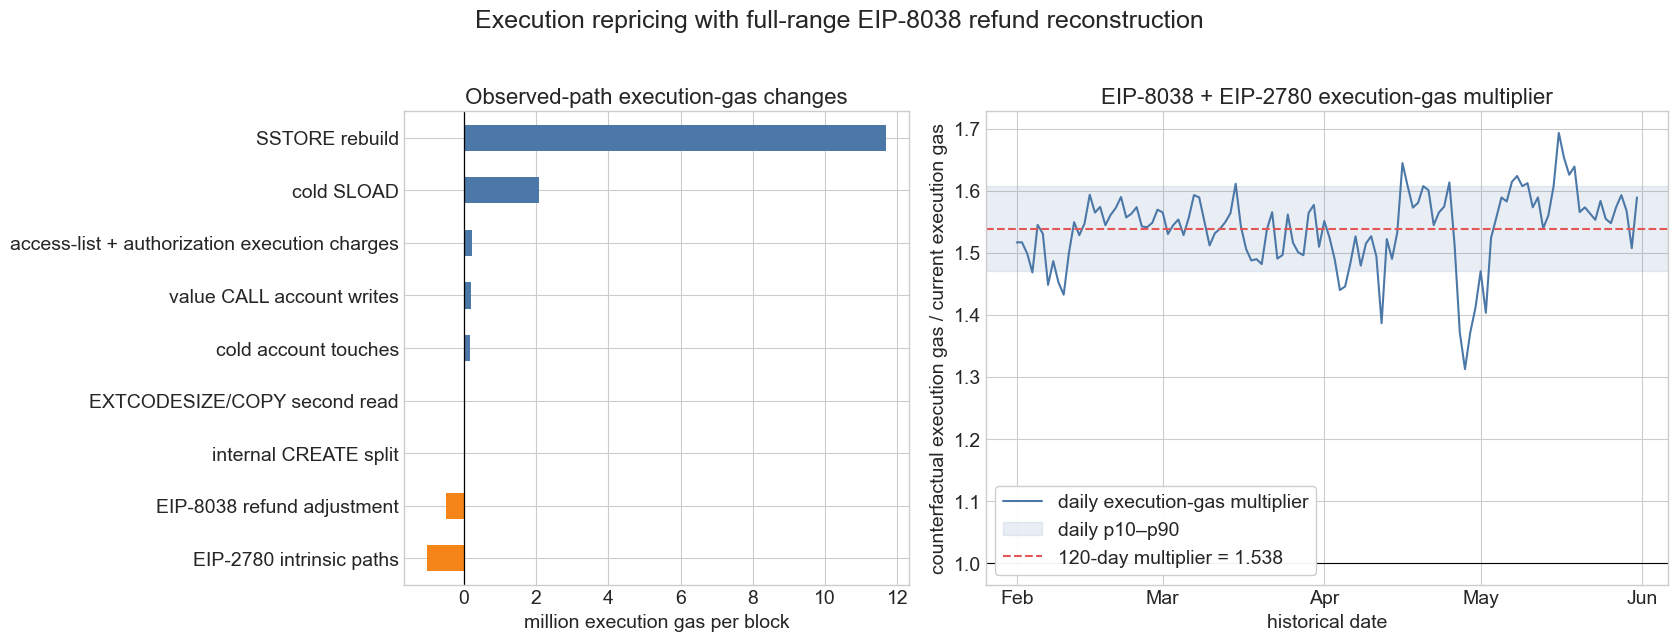

In [11]:
fig, axes = plt.subplots(
    1, 2, figsize=(17, 6.3), gridspec_kw={"width_ratios": [1.0, 1.35]}
)

component_per_block_m = component_per_block / 1e6
ordered = component_per_block_m.sort_values()
colors = ["#4c78a8" if value >= 0 else "#f58518" for value in ordered]
ordered.plot.barh(ax=axes[0], color=colors)
axes[0].axvline(0, color="black", linewidth=0.9)
axes[0].set_title("Observed-path execution-gas changes")
axes[0].set_xlabel("million execution gas per block")
axes[0].set_ylabel("")

plot_daily = daily.sort_values("date")
m = plot_daily["m_execution_8038_2780_refund_corrected_daily"]
p10, p90 = m.quantile([0.10, 0.90])
axes[1].plot(
    plot_daily["date"], m, color="#4c78a8", linewidth=1.5,
    label="daily execution-gas multiplier",
)
axes[1].axhspan(p10, p90, color="#4c78a8", alpha=0.12, label="daily p10–p90")
axes[1].axhline(
    pooled_multiplier,
    color="#e45756",
    linestyle="--",
    linewidth=1.5,
    label=f"120-day multiplier = {pooled_multiplier:.3f}",
)
axes[1].axhline(1, color="black", linewidth=0.8)
axes[1].set_title("EIP-8038 + EIP-2780 execution-gas multiplier")
axes[1].set_ylabel("counterfactual execution gas / current execution gas")
axes[1].set_xlabel("historical date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[1].legend(loc="lower left", frameon=True, framealpha=0.95)
fig.suptitle(
    "Execution repricing with full-range EIP-8038 refund reconstruction",
    y=1.02,
    fontsize=18,
)
fig.tight_layout()
fig.savefig(OUT_PLOT, dpi=180, bbox_inches="tight")
plt.show()

## Interpretation

The full Xatu calculation covers all **67.64 million** refund-positive transactions in the 120-day range. The integer reconstruction identifies 99.78% of those transactions and 99.82% of the observed refund counter; the remaining counter receives the same daily correction rate as the identified transactions.

The EIP-8038 counter is about 15.0% larger than the current counter over the identified transactions. Repricing also raises the cap denominator, so transactions that are currently capped can claim more of the reconstructed counter. After the transaction-level cap and current calldata floor are applied, the pooled execution multiplier falls from the provisional fixed-refund value of about 1.558 to about **1.538**.

Using the EIP-7976 calldata floor inside the refund calculation gives a slightly higher multiplier because the larger floor masks some refunds. It is reported as a sensitivity because the separate data multiplier already captures EIP-7976, while the execution headline is intended to isolate regular-execution repricing.

The important remaining approximation is not sample size or RPC coverage. It is the allocation of non-storage regular- and state-gas changes to individual refund-positive transactions when constructing the counterfactual cap denominator. Storage changes are transaction-specific; the other changes use the pooled full-panel Xatu/accounting ratio. The refund-counter equations and their daily totals use the complete historical range.

In [12]:
assert CURRENT_EIP7904_COMPUTE_DELTA == 0
assert scenarios["m_execution_refund_corrected"].nunique() == 1
assert len(refund_daily) == 120
assert refund_coverage.loc[0, "transaction_identification_share"] > 0.99
assert refund_coverage.loc[0, "refund_counter_identification_share"] > 0.99
assert pooled_bound_low <= pooled_multiplier <= pooled_bound_high
assert pooled_multiplier < pooled_fixed_refund_multiplier
assert set(pd.to_datetime(daily["date"]).dt.strftime("%Y-%m-%d")) == set(
    pd.date_range(START_DATE, periods=120, freq="D").strftime("%Y-%m-%d")
)
print(f"corrected pooled execution multiplier: {pooled_multiplier:.6f}")
print(f"fixed-refund comparison: {pooled_fixed_refund_multiplier:.6f}")
print(f"EIP-7976 floor sensitivity: {pooled_7976_floor_multiplier:.6f}")
print("wrote", OUT_SPEC_CSV)
print("wrote", OUT_DAILY_CSV)
print("wrote", OUT_SCENARIOS_CSV)
print("wrote", OUT_PLOT)

corrected pooled execution multiplier: 1.537898
fixed-refund comparison: 1.558430
EIP-7976 floor sensitivity: 1.538449
wrote /Users/william/PycharmProjects/eip-7999-research/data/execution_repricing_spec_card_2026-02-01_2026-06-01.csv
wrote /Users/william/PycharmProjects/eip-7999-research/data/execution_repricing_daily_2026-02-01_2026-06-01.csv
wrote /Users/william/PycharmProjects/eip-7999-research/data/execution_repricing_scenarios_2026-02-01_2026-06-01.csv
wrote /Users/william/PycharmProjects/eip-7999-research/plots/execution_repricing_8038_2780_2026-02-01_2026-06-01.png
